In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv("../data/processed/superstore_clean.csv",
                 parse_dates=['Order_Date', 'Ship_Date'])

In [5]:
monthly = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly.columns = ['Month', 'Sales']
monthly['Month'] = monthly['Month'].dt.to_timestamp()
monthly = monthly.set_index('Month').asfreq('MS')  # MS = Month Start frequency

print(f" Monthly time series prepared")
print(f"   Period: {monthly.index.min()} → {monthly.index.max()}")
print(f"   Total months: {len(monthly)}")
display(monthly.head(10))

 Monthly time series prepared
   Period: 2014-01-01 00:00:00 → 2017-12-01 00:00:00
   Total months: 48


,Sales
Month,
2014-01-01,3607.9050
2014-02-01,1912.6460
2014-03-01,7446.5820
2014-04-01,6805.4750
2014-05-01,5802.2250
2014-06-01,5174.8296
2014-07-01,6971.3110
2014-08-01,7980.4090
2014-09-01,11715.8000


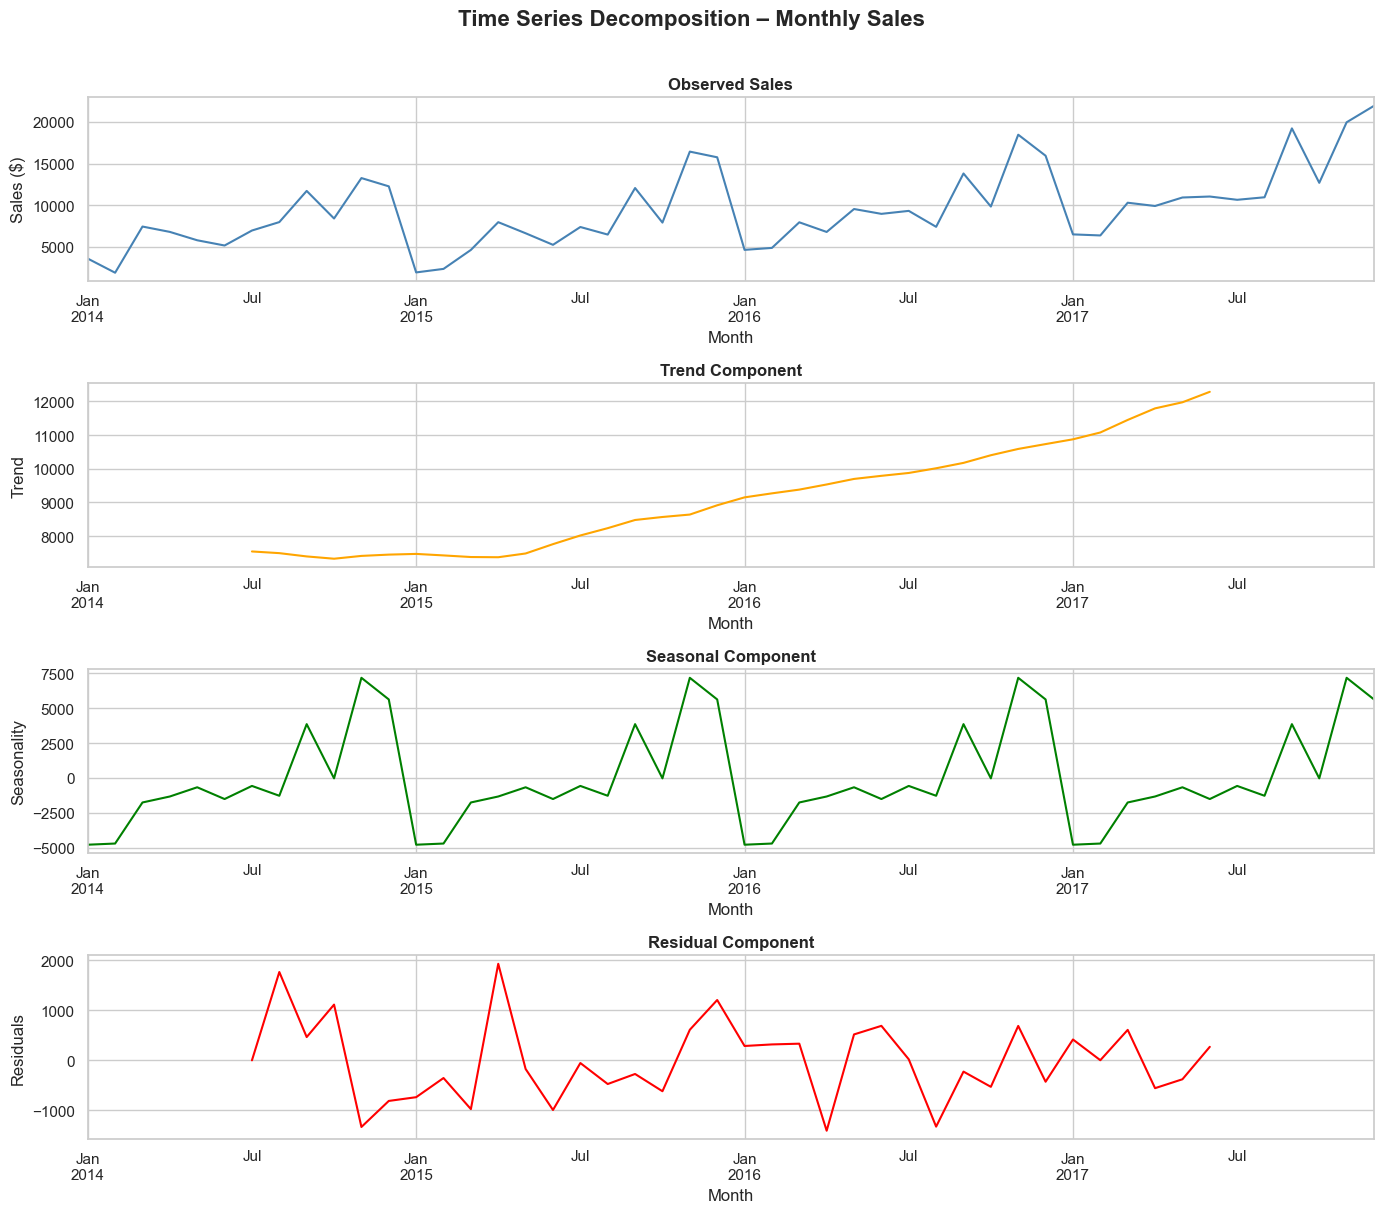

Observations:
  - Clear UPWARD trend in sales over 2015-2018
  - Strong seasonality with peaks in Q4 (holiday season)


In [6]:
decomposition = seasonal_decompose(monthly['Sales'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title("Observed Sales", fontweight='bold')
axes[0].set_ylabel("Sales ($)")

decomposition.trend.plot(ax=axes[1], color='orange')
axes[1].set_title("Trend Component", fontweight='bold')
axes[1].set_ylabel("Trend")

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title("Seasonal Component", fontweight='bold')
axes[2].set_ylabel("Seasonality")

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title("Residual Component", fontweight='bold')
axes[3].set_ylabel("Residuals")

plt.suptitle("Time Series Decomposition – Monthly Sales", 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Observations:")
print("  - Clear UPWARD trend in sales over 2015-2018")
print("  - Strong seasonality with peaks in Q4 (holiday season)")

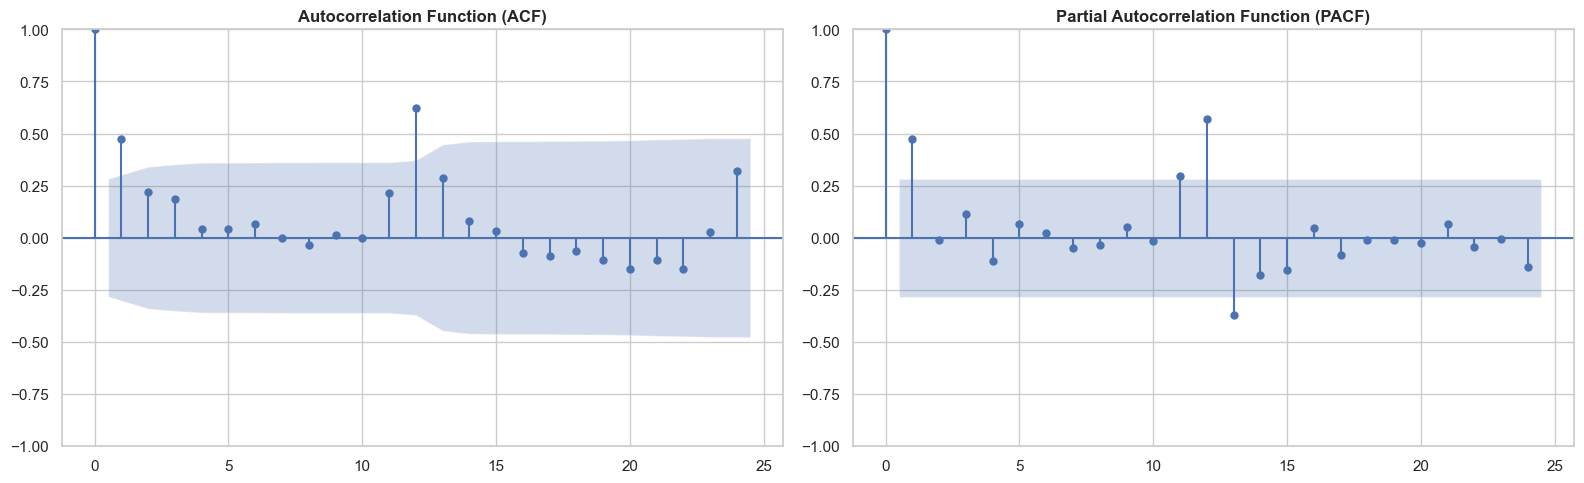

ACF/PACF help us choose SARIMA parameters (p, d, q)(P, D, Q)m


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(monthly['Sales'].dropna(), lags=24, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)", fontweight='bold')

plot_pacf(monthly['Sales'].dropna(), lags=24, ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function (PACF)", fontweight='bold')

plt.tight_layout()
plt.show()

print("ACF/PACF help us choose SARIMA parameters (p, d, q)(P, D, Q)m")

 Train/Test Split:
   Training: 2014-01-01 → 2016-12-01 (36 months)
   Testing : 2017-01-01 → 2017-12-01 (12 months)


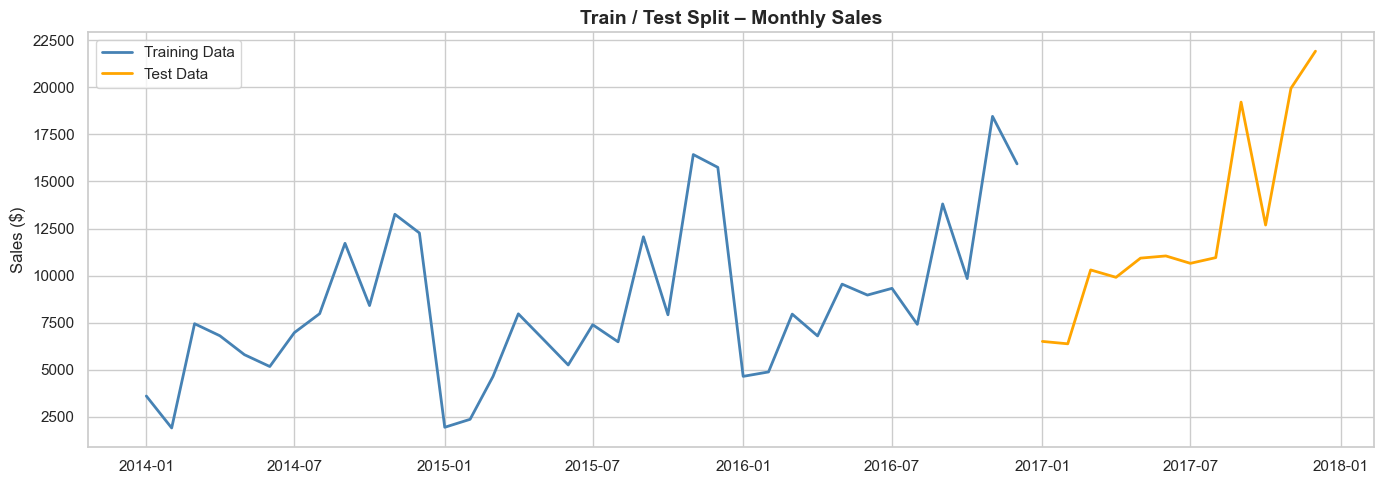

In [8]:
train_size = len(monthly) - 12
train = monthly.iloc[:train_size]
test  = monthly.iloc[train_size:]

print(f" Train/Test Split:")
print(f"   Training: {train.index.min().date()} → {train.index.max().date()} ({len(train)} months)")
print(f"   Testing : {test.index.min().date()} → {test.index.max().date()} ({len(test)} months)")

plt.figure(figsize=(14, 5))
plt.plot(train.index, train['Sales'], label='Training Data', color='steelblue', linewidth=2)
plt.plot(test.index,  test['Sales'],  label='Test Data', color='orange', linewidth=2)
plt.title("Train / Test Split – Monthly Sales", fontsize=14, fontweight='bold')
plt.ylabel("Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
model = SARIMAX(train['Sales'],
                order=(1, 1, 1),        
                seasonal_order=(1, 1, 1, 12), 
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit(disp=False)

print(" SARIMA model trained successfully!")
print(result.summary())

 SARIMA model trained successfully!
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -77.855
Date:                            Thu, 02 Apr 2026   AIC                            165.709
Time:                                    10:35:19   BIC                            166.695
Sample:                                01-01-2014   HQIC                           163.581
                                     - 12-01-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2777      0.849     -0.327      0.744      -1.941       1.386

In [10]:
forecast_steps = len(test)
forecast = result.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print(f" Forecast generated for {forecast_steps} months")
display(pd.DataFrame({
    'Actual': test['Sales'].values,
    'Forecast': forecast_mean.values,
    'Lower_CI': forecast_ci.iloc[:, 0].values,
    'Upper_CI': forecast_ci.iloc[:, 1].values
}, index=test.index).round(2))

 Forecast generated for 12 months


,Actual,Forecast,Lower_CI,Upper_CI
Month,,,,
2017-01-01,6506.93,6283.89,3018.83,9548.95
2017-02-01,6380.05,6183.13,2845.43,9520.82
2017-03-01,10301.60,9252.23,5892.14,12612.33
2017-04-01,9909.37,8741.96,5382.13,12101.79
2017-05-01,10928.22,10852.02,7488.97,14215.06
2017-06-01,11044.41,10150.52,6785.45,13515.60
2017-07-01,10651.76,10786.73,7419.31,14154.14
2017-08-01,10954.76,9056.15,5686.49,12425.82
2017-09-01,19210.28,15296.26,11924.32,18668.21


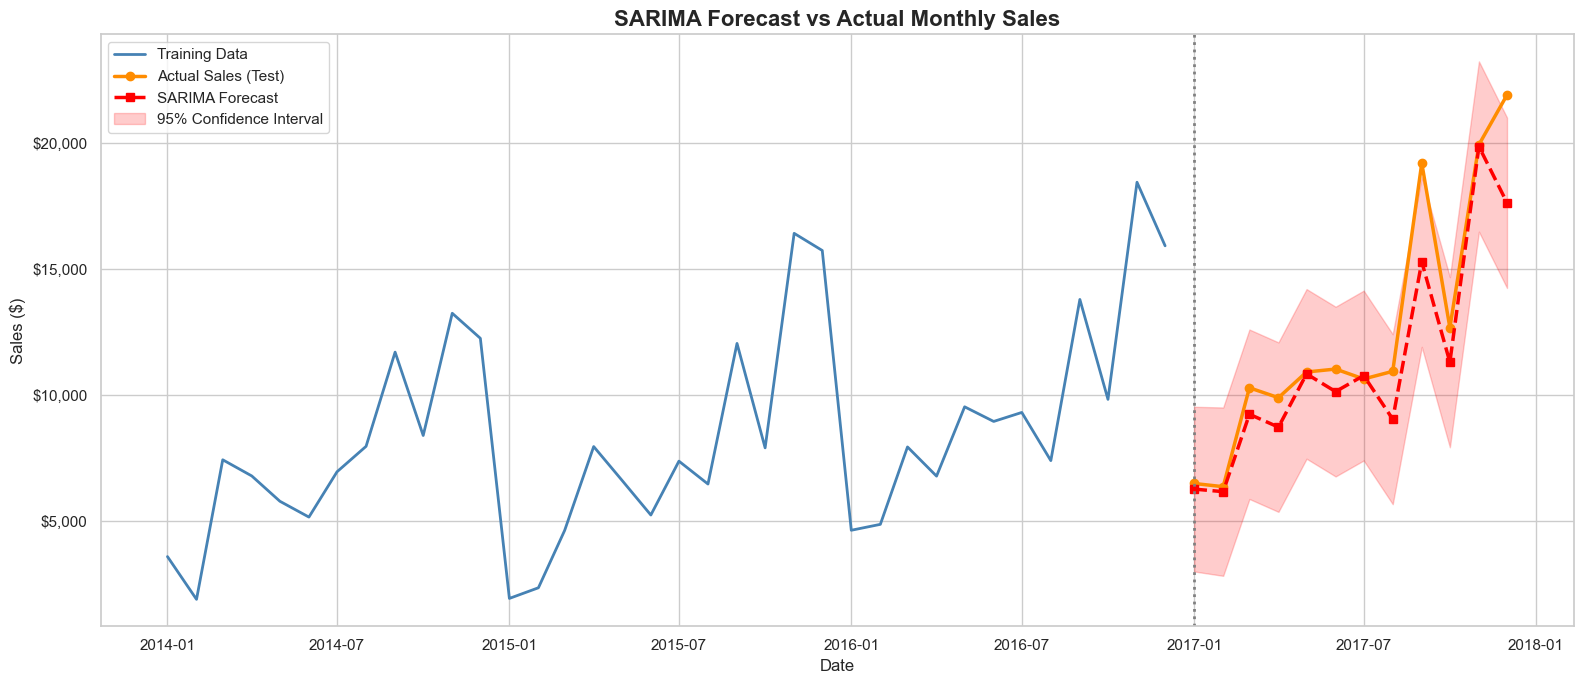

In [11]:
plt.figure(figsize=(16, 7))

# Training data
plt.plot(train.index, train['Sales'], 
         label='Training Data', color='steelblue', linewidth=2)

# Actual test data
plt.plot(test.index, test['Sales'], 
         label='Actual Sales (Test)', color='darkorange', linewidth=2.5, marker='o')

# Forecasted values
plt.plot(forecast_mean.index, forecast_mean, 
         label='SARIMA Forecast', color='red', linewidth=2.5, linestyle='--', marker='s')

# Confidence interval
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 alpha=0.2, color='red', label='95% Confidence Interval')

plt.title("SARIMA Forecast vs Actual Monthly Sales", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(fontsize=11)
plt.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=2, label='Forecast Start')
plt.tight_layout()
plt.show()

In [12]:
actual    = test['Sales'].values
predicted = forecast_mean.values

mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
r2   = 1 - (np.sum((actual - predicted)**2) / np.sum((actual - actual.mean())**2))


print("     FORECASTING MODEL PERFORMANCE METRICS")
print("-" * 50)
print(f"  MAE  (Mean Absolute Error)  : ${mae:,.2f}")
print(f"  RMSE (Root Mean Sq Error)   : ${rmse:,.2f}")
print(f"  MAPE (Mean Abs % Error)     : {mape:.2f}%")
print(f"  R²   (Coefficient of Det.)  : {r2:.4f}")

if mape < 10:
    print("  Excellent forecast (MAPE < 10%)")
elif mape < 20:
    print("  Good forecast (MAPE < 20%)")
else:
    print("  Model needs improvement (MAPE > 20%)")

     FORECASTING MODEL PERFORMANCE METRICS
--------------------------------------------------
  MAE  (Mean Absolute Error)  : $1,272.75
  RMSE (Root Mean Sq Error)   : $1,881.24
  MAPE (Mean Abs % Error)     : 8.91%
  R²   (Coefficient of Det.)  : 0.8507
  Excellent forecast (MAPE < 10%)


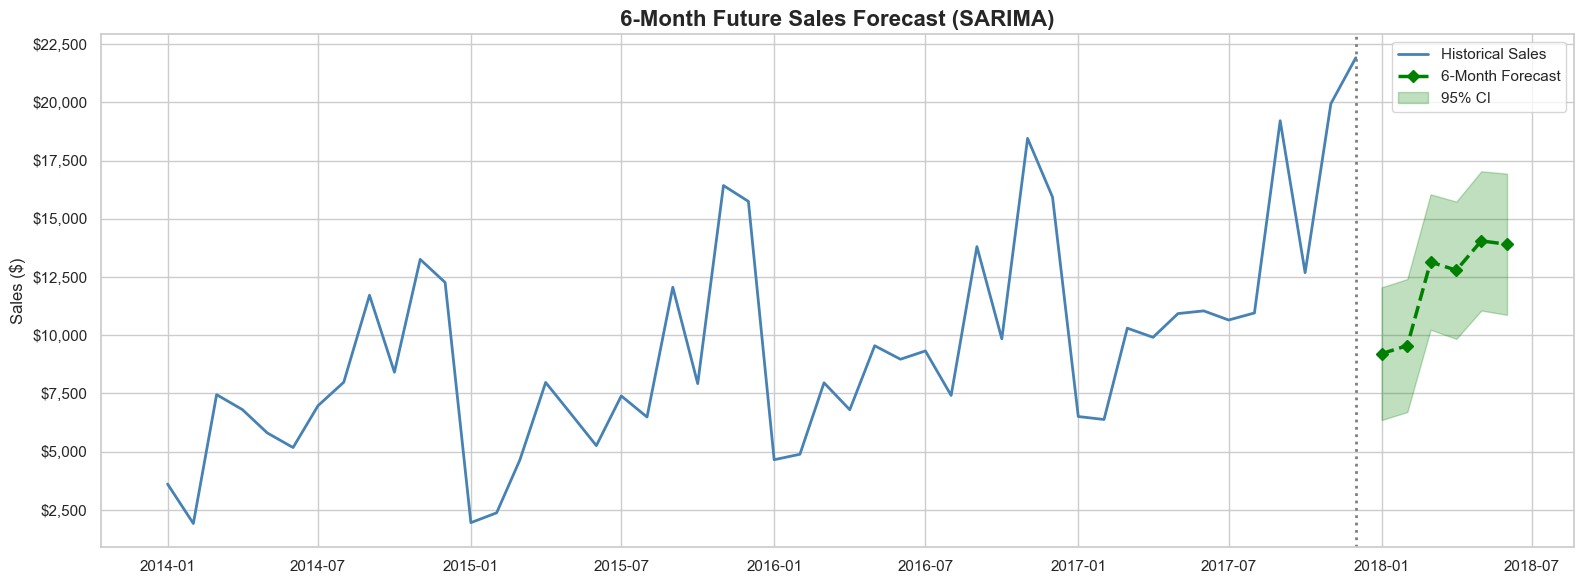


 Future Monthly Forecast:
  Jan 2018: $9,204.90
  Feb 2018: $9,555.00
  Mar 2018: $13,142.84
  Apr 2018: $12,789.06
  May 2018: $14,049.08
  Jun 2018: $13,904.94


In [14]:
full_model = SARIMAX(monthly['Sales'],
                     order=(1, 1, 1),
                     seasonal_order=(1, 1, 1, 12),
                     enforce_stationarity=False,
                     enforce_invertibility=False)

full_result = full_model.fit(disp=False)

future_forecast = full_result.get_forecast(steps=6)
future_mean = future_forecast.predicted_mean
future_ci   = future_forecast.conf_int()

# Plot
plt.figure(figsize=(16, 6))
plt.plot(monthly.index, monthly['Sales'], 
         label='Historical Sales', color='steelblue', linewidth=2)
plt.plot(future_mean.index, future_mean, 
         label='6-Month Forecast', color='green', linewidth=2.5, 
         linestyle='--', marker='D')
plt.fill_between(future_ci.index,
                 future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                 alpha=0.25, color='green', label='95% CI')
plt.axvline(x=monthly.index[-1], color='gray', linestyle=':', linewidth=2)
plt.title("6-Month Future Sales Forecast (SARIMA)", fontsize=16, fontweight='bold')
plt.ylabel("Sales ($)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.show()

print("\n Future Monthly Forecast:")
for date, val in zip(future_mean.index, future_mean.values):
    print(f"  {date.strftime('%b %Y')}: ${val:,.2f}")

In [15]:
total_forecast_6m = future_mean.sum()
current_avg       = monthly['Sales'].tail(12).mean()
forecast_avg      = future_mean.mean()
growth            = ((forecast_avg - current_avg) / current_avg) * 100

print(f"\nForecast Summary (Next 6 Months):")
print(f"   Total Projected Sales : ${total_forecast_6m:,.2f}")
print(f"   Current Avg (last 12m): ${current_avg:,.2f}/month")
print(f"   Forecast Avg          : ${forecast_avg:,.2f}/month")
print(f"   Projected Growth      : {growth:+.1f}%")


Forecast Summary (Next 6 Months):
   Total Projected Sales : $72,645.82
   Current Avg (last 12m): $12,535.76/month
   Forecast Avg          : $12,107.64/month
   Projected Growth      : -3.4%
